In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

2025-04-16 21:33:18.393157: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
## Data loading
df = pd.read_csv("datos_ambientales_numericos.csv")
# df = df[['temperatura', 'presion', 'humedad']]
df

,fecha,temperatura,presion,humedad,altura,alta_temperatura,nivel_temperatura
0,0.0,27.19,790.4434,25.17188,2046.082,1,4
1,123.0,27.44,790.3516,24.77051,2047.017,1,4
2,245.0,27.72,790.4346,24.71582,2046.172,1,4
3,367.0,27.61,790.4080,24.66504,2046.444,1,4
4,494.0,27.78,790.4640,24.65234,2045.873,1,4
...,...,...,...,...,...,...,...
700,85885.0,26.59,788.6235,23.09961,2064.625,1,3
701,86007.0,26.58,788.6169,23.08496,2064.694,1,3
702,86129.0,26.57,788.5771,23.09473,2065.101,1,3
703,86251.0,26.57,788.6313,23.08887,2064.546,1,3


In [3]:
# Normalization
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 3. Crear secuencias para entrenamiento (ventanas deslizantes)
def crear_secuencias(data, n_steps):
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i - n_steps:i, 1:])  # presion y humedad
        y.append(data[i, 0])               # temperatura
    return np.array(X), np.array(y)

n_steps = 10  # Número de pasos temporales
X, y = crear_secuencias(scaled_data, n_steps)

# 4. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. Construir modelo LSTM
model = Sequential()
model.add(LSTM(64, return_sequences=False, input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))  # Predicción de temperatura
model.compile(optimizer='adam', loss='mse')

# 6. Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)

2025-04-16 21:33:49.252671: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.
2025-04-16 21:33:51.020204: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:33:51.023978: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:33:51.0

Epoch 1/50


2025-04-16 21:33:51.895745: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:33:51.898705: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:33:51.901607: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

16/16 [==============================] - ETA: 0s - loss: 0.0464

2025-04-16 21:33:56.200049: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:33:56.202832: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:33:56.204981: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

16/16 [==============================] - 5s 74ms/step - loss: 0.0464 - val_loss: 0.3821
Epoch 2/50
16/16 [==============================] - 0s 20ms/step - loss: 0.0144 - val_loss: 0.0726
Epoch 3/50
16/16 [==============================] - 0s 21ms/step - loss: 0.0092 - val_loss: 0.0363
Epoch 4/50
16/16 [==============================] - 0s 23ms/step - loss: 0.0071 - val_loss: 0.0091
Epoch 5/50
16/16 [==============================] - 0s 25ms/step - loss: 0.0055 - val_loss: 7.6230e-04
Epoch 6/50
16/16 [==============================] - 0s 25ms/step - loss: 0.0044 - val_loss: 0.0097
Epoch 7/50
16/16 [==============================] - 0s 21ms/step - loss: 0.0038 - val_loss: 0.0151
Epoch 8/50
16/16 [==============================] - 0s 21ms/step - loss: 0.0033 - val_loss: 0.0099
Epoch 9/50
16/16 [==============================] - 0s 23ms/step - loss: 0.0029 - val_loss: 0.0108
Epoch 10/50
16/16 [==============================] - 0s 18ms/step - loss: 0.0027 - val_loss: 0.0024
Epoch 11/50
16/1

2025-04-16 21:34:36.905624: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:34:36.908096: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:34:36.910772: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

5/5 [==============================] - 1s 15ms/step


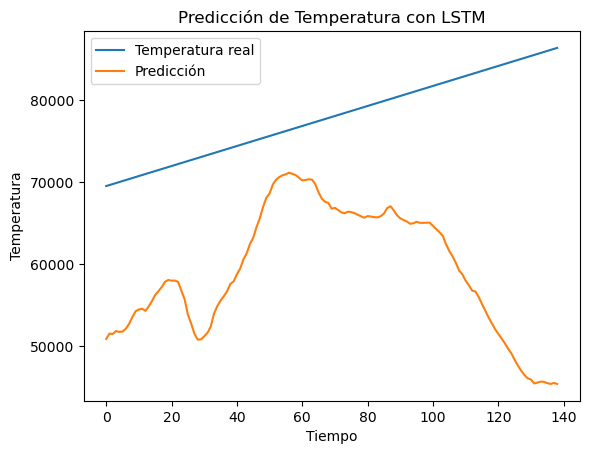

In [4]:

# 7. Evaluar y graficar resultados
predicted = model.predict(X_test)
predicted_temp = scaler.inverse_transform(
    np.hstack((predicted, X_test[:, -1, :]))
)[:, 0]  # Reconstruimos el valor de temperatura original
real_temp = scaler.inverse_transform(
    np.hstack((y_test.reshape(-1,1), X_test[:, -1, :]))
)[:, 0]

# 8. Gráfico de predicciones vs reales
plt.plot(real_temp, label='Temperatura real')
plt.plot(predicted_temp, label='Predicción')
plt.legend()
plt.title("Predicción de Temperatura con LSTM")
plt.xlabel("Tiempo")
plt.ylabel("Temperatura")
plt.show()


Entrenando con optimizador: Adam


2025-04-16 21:37:22.491004: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:37:22.492964: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:37:22.494612: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Entrenando con optimizador: SGD


2025-04-16 21:37:53.159940: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:37:53.160971: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:37:53.162213: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Entrenando con optimizador: RMSprop


...

2025-04-16 21:38:43.518932: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:38:43.520048: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:38:43.521211: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Entrenando con optimizador: Adadelta


2025-04-16 21:39:07.873486: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:39:07.875066: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:39:07.876119: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Entrenando con optimizador: Nadam


2025-04-16 21:39:34.614294: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:39:34.615869: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:39:34.616786: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

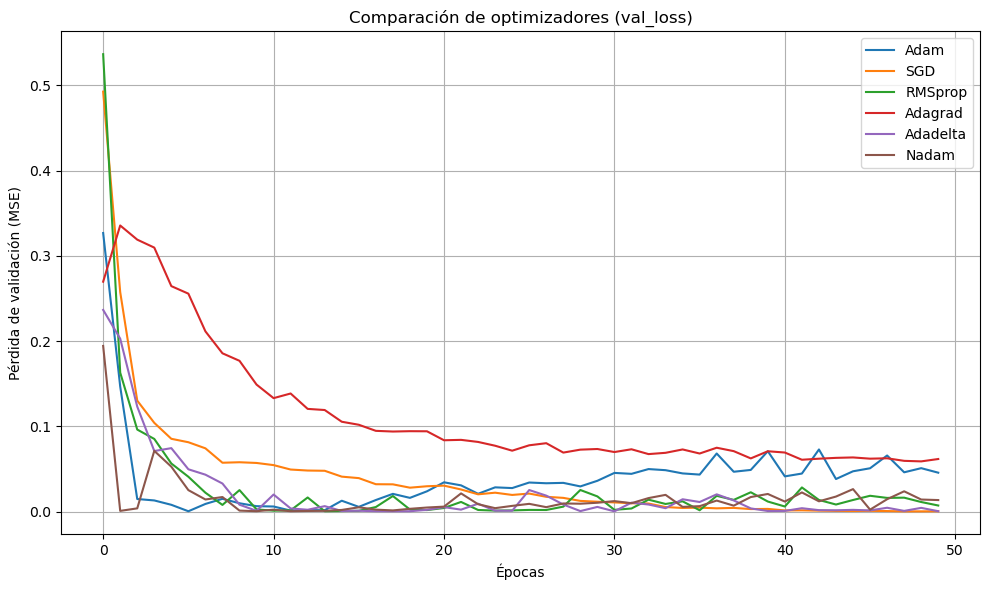


✅ Mejor optimizador: SGD


2025-04-16 21:40:06.647345: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-16 21:40:06.648449: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-16 21:40:06.649646: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

📦 Modelo guardado como 'modelo_mejor_optimizador.h5'
5/5 [==============================] - 0s 14ms/step


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad, Adadelta, Nadam

# Forzar ejecución eager
tf.config.run_functions_eagerly(True)

def crear_modelo(input_shape, optimizer):
    model = Sequential()
    model.add(LSTM(64, return_sequences=False, input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mse')
    return model

def crear_optimizador(nombre):
    """Crear un nuevo optimizador dado su nombre"""
    if nombre == 'Adam':
        return Adam(learning_rate=0.001)
    elif nombre == 'SGD':
        return SGD(learning_rate=0.01, momentum=0.9)
    elif nombre == 'RMSprop':
        return RMSprop(learning_rate=0.001)
    elif nombre == 'Adagrad':
        return Adagrad(learning_rate=0.01)
    elif nombre == 'Adadelta':
        return Adadelta(learning_rate=1.0)
    elif nombre == 'Nadam':
        return Nadam(learning_rate=0.002)
    else:
        raise ValueError(f"Optimizador {nombre} no reconocido")

def probar_y_guardar_mejor_modelo(X_train, y_train, X_test, y_test, optimizers_dict, epochs=30, batch_size=32):
    histories = {}
    val_losses_finales = {}

    for nombre, optim in optimizers_dict.items():
        print(f"Entrenando con optimizador: {nombre}")
        model = crear_modelo((X_train.shape[1], X_train.shape[2]), optim)
        history = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            verbose=0
        )
        histories[nombre] = history.history['val_loss']
        val_losses_finales[nombre] = history.history['val_loss'][-1]

    # Graficar pérdidas
    plt.figure(figsize=(10, 6))
    for nombre, val_loss in histories.items():
        plt.plot(val_loss, label=nombre)
    plt.title('Comparación de optimizadores (val_loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida de validación (MSE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Elegir el mejor optimizador
    mejor_optimizador = min(val_losses_finales, key=val_losses_finales.get)
    print(f"\n✅ Mejor optimizador: {mejor_optimizador}")

    # Reentrenar modelo con mejor optimizador (nuevo optimizador)
    nuevo_optimizer = crear_optimizador(mejor_optimizador)
    mejor_model = crear_modelo((X_train.shape[1], X_train.shape[2]), nuevo_optimizer)
    mejor_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    # Guardar el modelo
    save_model(mejor_model, 'modelo_mejor_optimizador.h5')
    print("📦 Modelo guardado como 'modelo_mejor_optimizador.h5'")

    # Hacer predicciones
    predicciones = mejor_model.predict(X_test)
    return predicciones, mejor_model, mejor_optimizador

# Definir optimizadores iniciales
optimizadores = {
    'Adam': Adam(learning_rate=0.001),
    'SGD': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': RMSprop(learning_rate=0.001),
    'Adagrad': Adagrad(learning_rate=0.01),
    'Adadelta': Adadelta(learning_rate=1.0),
    'Nadam': Nadam(learning_rate=0.002),
}

# Ejecutar
predicciones, modelo_final, mejor_opt = probar_y_guardar_mejor_modelo(
    X_train, y_train, X_test, y_test, optimizadores, epochs=50
)
